# Investment return comparison — driver

Thin orchestration over the three modules:

| module | role | reads | writes |
|---|---|---|---|
| `get_data.py` | fetch raw series (Ken French + CPI) | web | `data/raw/` |
| `process_data.py` | holding-period return distributions | `data/raw/` | `data/processed/` |
| `visualize.py` | diagnostic plots | `data/raw/` + `data/processed/` | — |

Three views (`config.SERIES`): **`excess_wealth`** (extra wealth per \$1 from the US market vs. holding the 1-month T-bill over the same window — `G_market − G_tbill`), **`real_market`** (US market deflated by CPI), **`real_tbill`** (T-bill deflated by CPI). The `usmkt` / `tbill` / `cpi` level series are built internally. All settings live in `config.py`.

In [ ]:
%load_ext autoreload
%autoreload 2

import config
import get_data
import process_data
import visualize

## 1. Fetch raw data
Plain downloads (Ken French factors + BLS CPI mirror). Only re-run for fresh data — the files under `data/raw/` are kept.

In [ ]:
# get_data.main()

## 2. Process
`config.SERIES`, both sweeps → `data/processed/`. Full 1926– history: a few minutes, ~1.3 GB.

In [ ]:
lv = process_data.levels()
for name in config.SERIES:
    lsrc, bsrc = process_data.SERIES_INPUTS[name]
    level, bench = lv[lsrc], (lv[bsrc] if bsrc else None)
    print(name, level.index.min().date(), '->', level.index.max().date(),
          f'({len(level)} obs)', f'vs {bsrc}' if bsrc else '')
    process_data.compute_and_save(level, name, bench=bench)

## 3. Visualise
`common` = every horizon shares the same start dates (comparable across horizons); `expanding` = every horizon uses all the starts it can.

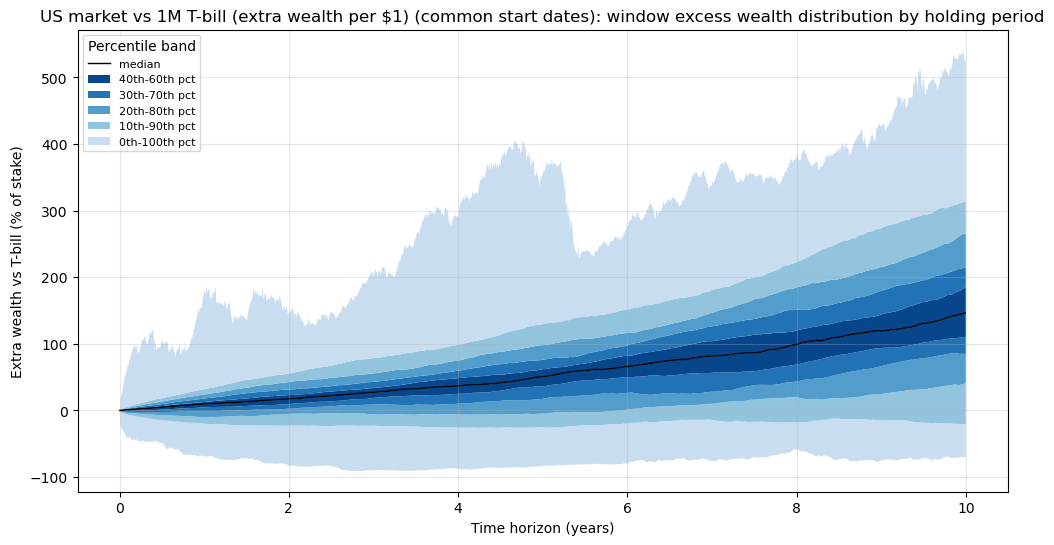

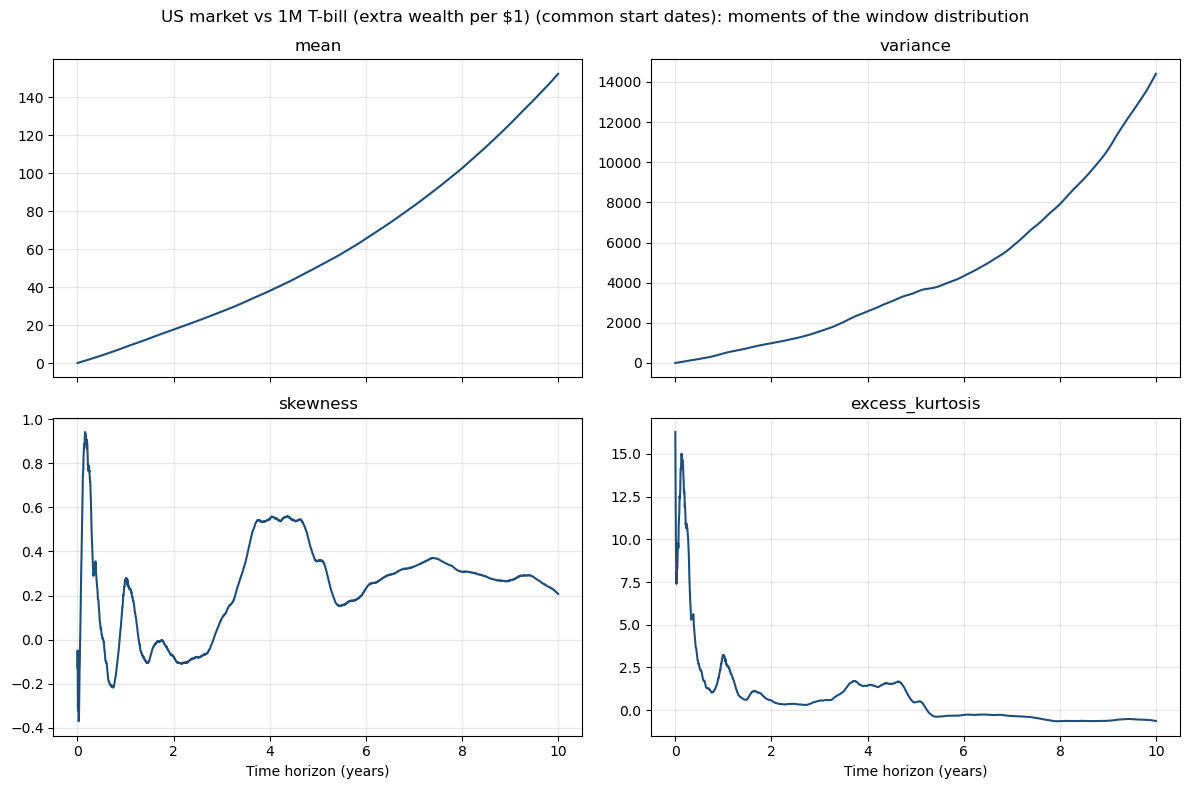

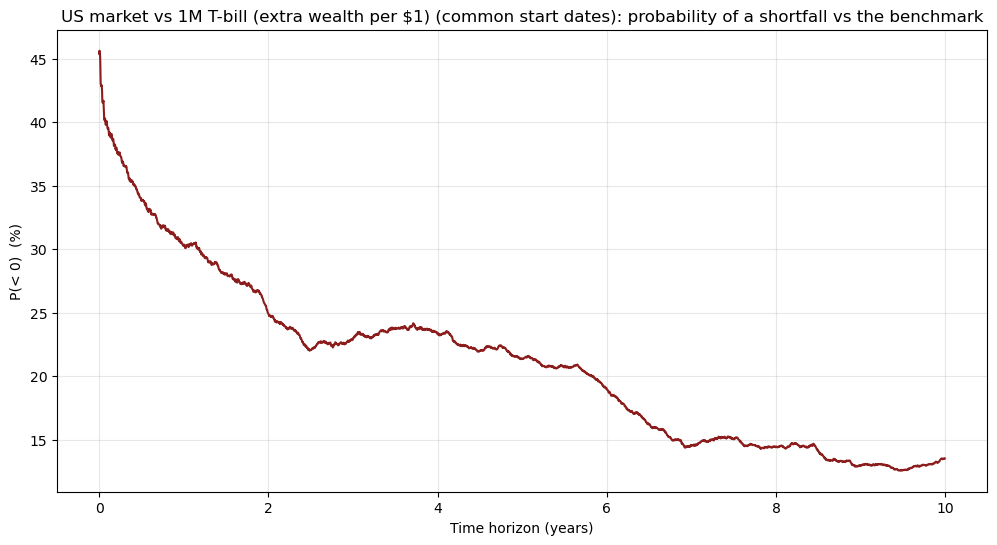

In [13]:
visualize.visualize_from_disk('excess_wealth', 'common')

In [ ]:
visualize.visualize_from_disk('real_market', 'common')

In [ ]:
visualize.visualize_from_disk('real_tbill', 'common')